In [3]:
import sys
print(sys.executable)

import yaml
print(yaml.__file__)

/home/lhe09/miniconda3/envs/first/bin/python
/home/lhe09/miniconda3/envs/first/lib/python3.10/site-packages/yaml/__init__.py


In [ ]:
#import yaml
import pandas as pd

#with open("../configs.yaml") as f:
#    cfg = yaml.safe_load(f)

# configs.yaml을 어디서든 열수 있는 프로젝트 root 기준으로 경로 만드는 법
from pathlib import Path
import yaml

ROOT = Path().resolve().parent   # notebooks 상위
config_path = ROOT / "configs.yaml"

with open(config_path) as f:
    cfg = yaml.safe_load(f)
# --------------------------------------
# 1. Load Meta Data
# --------------------------------------
label_df = pd.read_csv(cfg["data"]["train_label_csv"])
desc_df = pd.read_csv(cfg["data"]["train_desc_csv"])

print("Shape:", label_df.shape)

Shape: (48692, 7)


In [8]:
label_df.groupby(
    ["study_id", "series_id", "instance_number"]
).size().describe()

count    24546.000000
mean         1.983704
std          1.251497
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max         10.000000
dtype: float64

In [12]:
import os

print(cfg["data"]["train_images_root"])
print(os.path.exists(cfg["data"]["train_images_root"]))

/mnt/c/Users/lhe09/projects/rsna2024_spine/Data/train_images
True


In [ ]:
import os

base = "/mnt/c/Users/lhe09/projects/rsna2024_spine/Data/train_images"

study_id = 4003253
series_id = 702807833

path = os.path.join(base, str(study_id), str(series_id))

files = [f for f in os.listdir(path) if f.endswith(".dcm")]

print("slice 개수:", len(files))


slice 개수: 15


TypeError: 'str' object is not callable

In [19]:
import pydicom

path = "/mnt/c/Users/lhe09/projects/rsna2024_spine/Data/train_images/4003253/702807833"

import os
f = os.listdir(path)[0]

dcm = pydicom.dcmread(os.path.join(path, f))

print(dcm)

Dataset.file_meta -------------------------------
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Enhanced MR Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 4003253.1.1
(0002,0010) Transfer Syntax UID                 UI: RLE Lossless
(0002,0012) Implementation Class UID            UI: 1.2.40.0.13.1.1.1
(0002,0013) Implementation Version Name         SH: 'PYDICOM 2.4.2'
-------------------------------------------------
(0008,0018) SOP Instance UID                    UI: 4003253.1.1
(0008,0023) Content Date                        DA: '20240503'
(0008,0033) Content Time                        TM: '223718.007977'
(0008,103E) Series Description                  LO: 'T2'
(0010,0020) Patient ID                          LO: '4003253'
(0018,0050) Slice Thickness                     DS: '4.0'
(0018,0088) Spacing Between Slices              DS: '4.8'
(0018,5100) Patient Position                    CS: 'HFS'
(00

In [ ]:
#cycle error 
#< 1.0 px  매우 좋음
#< 0.5 px  strong
#< 0.2 px  매우 안정

In [ ]:
#failed_case 226개 발생() - 640, 608이라는 다른 해상도가 존재하였음
#실패케이스만 다시 돌림(35개 series)

#[INFO] existing rows: 664944
#[INFO] new rows: 10796
#[INFO] total saved rows: 675740

SyntaxError: invalid decimal literal (4170373295.py, line 1)

In [ ]:
#GT anchor
#   ↓
#Self-supervised registration
#   ↓
#Cycle consistency filtering
#   ↓
#Dense pseudo-label
#   ↓
#ROI multi-slice dataset

In [ ]:
# 코드 모두 수정함
# propagation.csv
# load dicom series
# 좌표별 ROI crop
# 9 slice stack
# disc별 sample 생성
# .pt 저장

In [1]:
# propagated_lavels.csv 확인(pre_process_all.py 확인(roi전))
import pandas as pd

df = pd.read_csv("../outputs/labels/propagated_labels.csv")
print(df.columns)
print(df.head())

Index(['study_id', 'series_id', 'anchor_instance', 'instance_number',
       'num_points', 'x_coords', 'y_coords', 'cycle_error', 'valid'],
      dtype='object')
   study_id  series_id  anchor_instance  instance_number  num_points  \
0   4003253  702807833                8                1           5   
1   4003253  702807833                8                2           5   
2   4003253  702807833                8                3           5   
3   4003253  702807833                8                4           5   
4   4003253  702807833                8                5           5   

                                            x_coords  \
0  [322.8570861816406, 320.5860595703125, 323.057...   
1  [322.85577392578125, 320.5853271484375, 323.05...   
2  [322.8543701171875, 320.5846252441406, 323.054...   
3  [322.85284423828125, 320.58392333984375, 323.0...   
4  [322.8512268066406, 320.5832214355469, 323.051...   

                                            y_coords  cycle_error  v

In [ ]:
import ast

sample = df.iloc[0]

x = ast.literal_eval(sample["x_coords"])
y = ast.literal_eval(sample["y_coords"])

print(len(x), len(y))
# num_points와 길이가 일치해야함.

5 5


In [ ]:
# 한 series가 slice 몇개를 가지고 있는지 확인
df.groupby(["study_id","series_id"]).size().describe()

count    6291.000000
mean      107.413766
std       114.076464
min         5.000000
25%        25.000000
50%        68.000000
75%       147.000000
max      1680.000000
dtype: float64

In [ ]:
# cycle_error상태 확인
df["cycle_error"].describe()
# 확인사항(평균이 너무 크지 않을 것!, 5이상 튀는 아이가 있는지 확인 할 것!)

# count(row) 676740 # slice * anchor(6291개의 series, 평균 107개의 slice)

# cycel_error(anchor-> slice -> anchor)의 의미
# < 0.05 매우 좋음
# < 0.1 정상
# < 0.3 borderline
# > 0.5 bad

count    675740.000000
mean          0.067478
std           0.083368
min           0.000000
25%           0.014848
50%           0.037468
75%           0.098989
max           1.041625
Name: cycle_error, dtype: float64

In [ ]:
# cycle_error valid 비율 확인
df["valid"].value_counts(normalize=True)
# valid 1 -> 95%이상이여야 정상

# 보통 propagation에서 valid ratio의 의미
# 70% 보통
# 80~90% 좋음
# > 90% 매우 좋음

valid
1    0.954071
0    0.045929
Name: proportion, dtype: float64

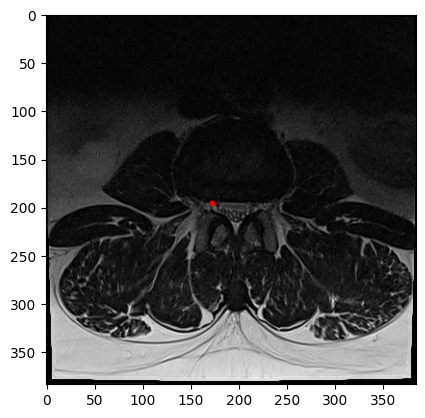

In [12]:
# series 하나 골라서 무작위 시각화
import os
import ast
import pydicom
import matplotlib.pyplot as plt
import yaml

with open("../configs.yaml") as f:
    cfg = yaml.safe_load(f)

ROOT = cfg["data"]["train_images_root"]

sample = df.iloc[1050]

x = ast.literal_eval(sample["x_coords"])
y = ast.literal_eval(sample["y_coords"])

img_path = os.path.join(
    ROOT,
    str(sample.study_id),
    str(sample.series_id),
    f"{sample.instance_number}.dcm"
)

dcm = pydicom.dcmread(img_path)
img = dcm.pixel_array

plt.imshow(img, cmap="gray")
plt.scatter(x, y, c="r", s=10)
plt.show()

In [14]:
sample = df.iloc[1050]

print(sample)

study_id                       7143189
series_id                   1951927562
anchor_instance                     17
instance_number                      7
num_points                           1
x_coords           [172.0594482421875]
y_coords           [195.3032684326172]
cycle_error                   0.092315
valid                                1
Name: 1050, dtype: object


In [18]:
import pandas as pd
df = pd.read_csv("/mnt/c/Users/lhe09/projects/rsna2024_spine/Data/train.csv")
print(df.columns)

Index(['study_id', 'spinal_canal_stenosis_l1_l2',
       'spinal_canal_stenosis_l2_l3', 'spinal_canal_stenosis_l3_l4',
       'spinal_canal_stenosis_l4_l5', 'spinal_canal_stenosis_l5_s1',
       'left_neural_foraminal_narrowing_l1_l2',
       'left_neural_foraminal_narrowing_l2_l3',
       'left_neural_foraminal_narrowing_l3_l4',
       'left_neural_foraminal_narrowing_l4_l5',
       'left_neural_foraminal_narrowing_l5_s1',
       'right_neural_foraminal_narrowing_l1_l2',
       'right_neural_foraminal_narrowing_l2_l3',
       'right_neural_foraminal_narrowing_l3_l4',
       'right_neural_foraminal_narrowing_l4_l5',
       'right_neural_foraminal_narrowing_l5_s1',
       'left_subarticular_stenosis_l1_l2', 'left_subarticular_stenosis_l2_l3',
       'left_subarticular_stenosis_l3_l4', 'left_subarticular_stenosis_l4_l5',
       'left_subarticular_stenosis_l5_s1', 'right_subarticular_stenosis_l1_l2',
       'right_subarticular_stenosis_l2_l3',
       'right_subarticular_stenosis_l3_l4',
 

In [ ]:
# 이후 bulid_roi_dataset.py로 roi 이미지를 잘라서 pt를 만듦
# progatated slice모두를 사용하는것이 아니라 center_idx를 가지고와 주변 9개의 slice만 사용하여 disc 중심의 ROI crop을 생성

In [ ]:
# 이후 ResNet 3D or ViT
# attention vs propagated coord 
# distance

In [ ]:
# build_roi_dataset.py는 6279개의 series그룹이 돌아감.

In [19]:
import torch

x = torch.load("/home/lhe09/projects/rsna_spine/outputs/roi_dataset/100.pt")

print(x["image"].shape)
print(x["label"])
print(x["level"])
print(x["coord"])

torch.Size([9, 224, 224])
tensor([0, 0, 0, 0, 0])
L2/L3
tensor([198.2609, 285.6027])


/tmp/ipykernel_942088/2083069945.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load("/home/lhe09/projects/rsna_spine/outputs/roi_dataset/100.pt")


In [20]:
import torch
import os
import random

path = "/home/lhe09/projects/rsna_spine/outputs/roi_dataset"

files = os.listdir(path)

for f in random.sample(files, 10):
    x = torch.load(os.path.join(path,f))
    print(x["label"])

tensor([2, 0, 0, 2, 2])
tensor([0, 0, 0, 0, 0])
tensor([2, 1, 0, 2, 1])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 1, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0])


/tmp/ipykernel_942088/2768576486.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load(os.path.join(path,f))


/tmp/ipykernel_942088/1473662205.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load(os.path.join(path, f))


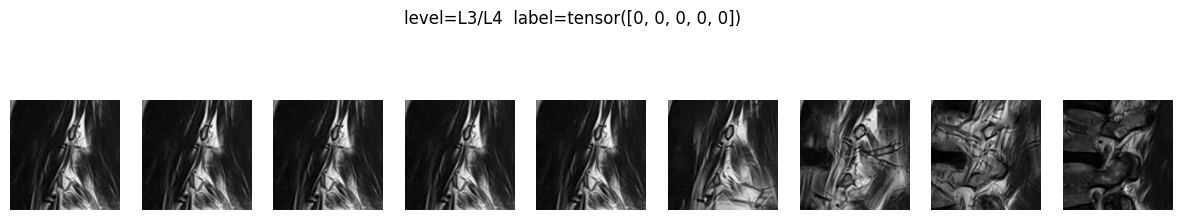

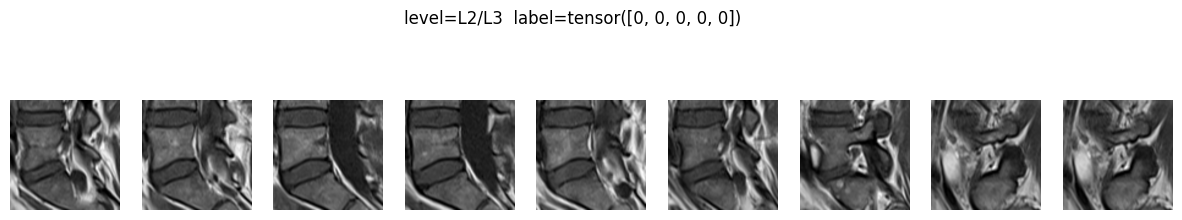

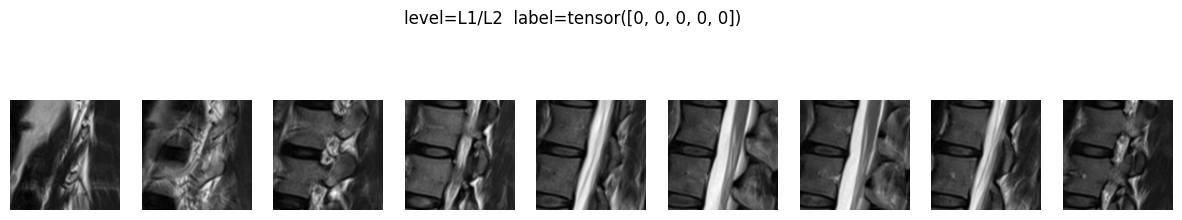

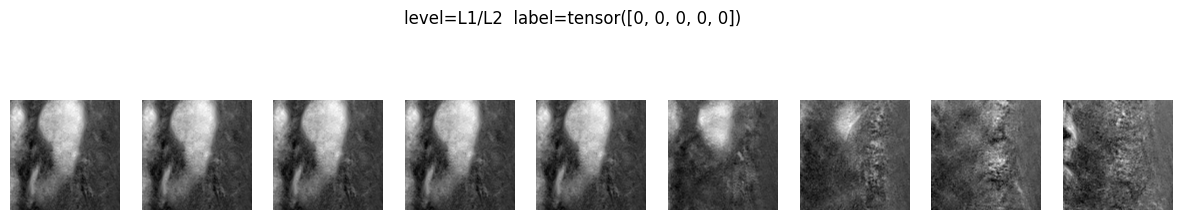

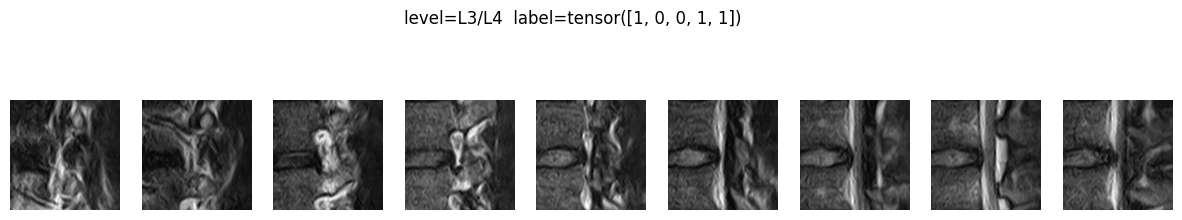

In [21]:
# ROI 시각화 propaation 품질 확인
import torch
import os
import matplotlib.pyplot as plt
import random

path = "/home/lhe09/projects/rsna_spine/outputs/roi_dataset"
files = os.listdir(path)

for f in random.sample(files, 5):

    x = torch.load(os.path.join(path, f))

    imgs = x["image"]

    fig, axs = plt.subplots(1,9, figsize=(15,3))

    for i in range(9):
        axs[i].imshow(imgs[i], cmap="gray")
        axs[i].axis("off")

    plt.suptitle(f"level={x['level']}  label={x['label']}")
    plt.show()

In [23]:
# label Distribution 분석(class imbalance가 심해 loss weighting이 필요함)
import torch
import os
import numpy as np

path = "/home/lhe09/projects/rsna_spine/outputs/roi_dataset"
files = os.listdir(path)

labels = []

for f in files[:20000]:
    x = torch.load(os.path.join(path,f))
    labels.append(x["label"].numpy())

labels = np.stack(labels)

print("shape:", labels.shape)

for i,name in enumerate([
    "canal",
    "left_foraminal",
    "right_foraminal",
    "left_subarticular",
    "right_subarticular"
]):
    valid = labels[:,i]
    valid = valid[valid >= 0]   # ⭐ -1 제거

    print(name, np.bincount(valid))    

/tmp/ipykernel_942088/4149464643.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load(os.path.join(path,f))


shape: (20000, 5)
canal [18114  1272   614]
left_foraminal [17303  2311   363]
right_foraminal [17248  2306   362]
left_subarticular [15553  2639  1109]
right_subarticular [15504  2768  1049]


In [24]:
print(x.keys())

dict_keys(['image', 'label', 'level', 'coord', 'study_id', 'series_id', 'instance_number', 'cycle_error'])


In [ ]:
## 학습 전략
# Experiment 1 - CNN + LSTM
# slice CNN -> LSTM -> classifier

In [ ]:
# Experiment 2 - Guided Attention(CNN + guided attention + lstm)
# feautere map(CNN) -> coordinate gaussian attention -> LSTM

# gaussian Attention
# 주변도 확인가능(공간적으로 퍼진 정보를 feature 자체로 바꿔버려서 noise가 제거됨.)
# coord만으로는 모델이 무시할 수 있는 정보라면 gaussian은 feature를 바꾸기 때문에 더 효과적임.
# 나의 경우에는 propagation으로 이미 약간의 오차가 있어 퍼진건 좋지만, 피처를 바꿔버리는 건 오차를 키워 학습이 망가질 위험이 생김
# -> coord guided를 하거나, gaussian을 약하게 넣거나, (attention에만 가우시안을 사용)attention weight에 bias정도로 사용

In [ ]:
# Experiment 3 - Transformer(CNN + transformer)
# slice feature -> transformer encoder -> classifier

In [ ]:
## 평가 방법
# Accuracy(기본 성능)
# F1(imbalance 데이터라서)
# AUC
# GradCAM(visualization)

In [ ]:
# spine_dataset으로 데이터 나눔
# building study map...
# total studies: 1973
# train studies: 1578
# val studies: 395
# train samples: 281000
# val samples: 70000
# 총 351,783개의 samples
# weight는 imbalance 때문에 normal- 0.1, moderate - 1.0, severe - 2.0으로 함.
# 모델은 ConvNext-Base으로 하려고 했는데, 메모리 부족으로(batch를 줄이는 것보다) ConvNext-Tiny로 수정
# .pt로 진행을 하려고 하는데, 로딩하는 시간과 메모리 부족으로 터져서, .npy파일로 모아 mmap방식을 쓰기로 함.
# mmap_mode="r"은 디스크처럼 내가 지정하는 정보만 골라 가지고 와서 메모리 거의 안씀

In [2]:
import torch

data = torch.load("../outputs/roi_dataset/1000.pt")
print(data["image"].dtype)
print(data["image"].shape)

torch.float16
torch.Size([9, 224, 224])


/tmp/ipykernel_1406/2367569391.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("../outputs/roi_dataset/1000.pt")


In [ ]:
# 그래서 pt를 npy로 변환할 conver_pt_to_npy.py를 돌리고 (351783개의.pt파일을 coord, images, labels, levels npy 파일로 변환)
# spine_dataset.py를 수정하여 experiment1.py를 돌림.

In [ ]:
import numpy as np

N = 351783

images = np.memmap(
    "/home/lhe09/projects/rsna_spine/outputs/roi_dataset_npy/images.npy",
    dtype=np.float16,
    mode="r",
    shape=(N,9,224,224)
)

labels = np.memmap(
    "/home/lhe09/projects/rsna_spine/outputs/roi_dataset_npy/labels.npy",
    dtype=np.int64,
    mode="r",
    shape=(N,5)
)

coords = np.memmap(
    "/home/lhe09/projects/rsna_spine/outputs/roi_dataset_npy/coords.npy",
    dtype=np.float32,
    mode="r",
    shape=(N,2)
)

levels = np.memmap(
    "/home/lhe09/projects/rsna_spine/outputs/roi_dataset_npy/levels.npy",
    dtype=np.int64,
    mode="r",
    shape=(N,)
)

print(images.shape)
print(labels.shape)
print(images[0].shape)
print(labels[0])

(351783, 9, 224, 224)
(351783, 5)


In [ ]:
# VAL ACC: 0.2819068194093067
# VAL F1: 0.12292730466065242
# VAL AUC: 0.49939256896515827
# 시간은 100시간이고, 정확도는 이상해서 수정..
# 라벨에서 심각도 [0, 1, 2]에서 [0]의 샘플이 너무 많아 1/3만 사용하기로 함.
# 스케쥴러 사용
# 여전히 ACU가 50을 넘지 않아서, 
# 20%로 imbalence 줄이고, weight도 수정함.
# 그리고 focal loss를 사용하고, lstm도 attn으로 주요 slice에 더 weight가 가도록 만듬.
# -> 정확도는 떨어지고(최고 45), AUC 80이상 나옴. 
# 그래서 argmax대신 Theshold를 사용하여 정확도를 높여보려고 함.

In [ ]:
# threshold를 지정해서 돌렸더니 정확도도, AUC도 다 안나와서, 
# 제대로 된 Threshold를 찾아야함.

In [2]:
import torch
import numpy as np
from torch.utils.data import DataLoader
import sys
sys.path.append("/home/lhe09/projects/rsna_spine/src")
from spine_dataset import build_datasets
from experiment3 import SpineModel

DEVICE = "cuda"

model = SpineModel().to(DEVICE)
model.load_state_dict(torch.load("/home/lhe09/projects/rsna_spine/outputs/results/best_model_convnext_transformer.pth"))
model.eval()


/tmp/ipykernel_1900/613214151.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home/lhe09/projects/rsna_spine/outputs/results/best_mod

SpineModel(
  (backbone): ConvNeXt(
    (stem): Sequential(
      (0): Conv2d(1, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (stages): Sequential(
      (0): ConvNeXtStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): ConvNeXtBlock(
            (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Linear(in_features=96, out_features=384, bias=True)
              (act): GELU()
              (drop1): Dropout(p=0.0, inplace=False)
              (norm): Identity()
              (fc2): Linear(in_features=384, out_features=96, bias=True)
              (drop2): Dropout(p=0.0, inplace=False)
            )
            (shortcut): Identity()
            (drop_path): Identity()
          )
          (1): ConvNeXtBlock(
            (conv_dw): Con

In [4]:
DATA_PATH = "/home/lhe09/projects/rsna_spine/outputs/roi_dataset_npy"

train_dataset, val_dataset = build_datasets(DATA_PATH)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=4
)

all_probs = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        img = batch["image"].to(DEVICE)
        label = batch["label"].to(DEVICE)
        #coord = batch["coord"].to(DEVICE) # experiment2

        #pred = model(img)
        pred = model(img) # experiment2
        prob = torch.softmax(pred, dim=-1)

        all_probs.append(prob.cpu().numpy())
        all_labels.append(label.cpu().numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

Total samples: 351783
Train samples: 316604
Val samples: 35179


In [ ]:
best_acc = 0

for t2 in np.arange(0.2, 0.5, 0.05):
    for t1 in np.arange(0.3, 0.6, 0.05):

        pred_cls = np.zeros_like(all_labels)

        pred_cls[all_probs[:,:,2] > t2] = 2
        mask = (all_probs[:,:,1] > t1) & (pred_cls != 2)
        pred_cls[mask] = 1

        acc = np.mean(pred_cls == all_labels)

        if acc > best_acc:
            best_acc = acc
            best_t1 = t1
            best_t2 = t2

print("BEST:", best_acc, best_t1, best_t2)


BEST: 0.8523578026251823 0.5499999999999999 0.44999999999999996


In [ ]:
# 데이터 분할 할때 램덤시드 고정 아직 안함.(그래서 정확도, F1, ACU 마구 흔들림)그래서 우선 고정함.(지금은 비교를 위해)
# 정확도 등을 올리기 위해 disc 별 weight과 dropout 추가함.
# 추가로 focalloss에서 entropyloss에 label smoothing으로 수정함
# -> 왜냐하면 AUC가 높음으로 구분은 잘하지만 ACC/F1이 낮은 이유는 확신(라벨)이 이상함
# 그래서 어려운 샘플에 집중하는 focalloss보다 probability를 부드럽게 해주고, threshold를 잘 먹히게 해주는 label smoothing이 나을 거임.

In [ ]:
# label smothooing + disc weight으로 정확도 68, AUC 50으로 됨.
# 근데 3 epoch에서 train loss가 nan이뜸. lstm에서 gradient clipping이 생긴건지, lr 낮추고 다시 시작해봄.
#Epoch 6
#Train Loss: 0.7916691594995783
#VAL ACC: 0.7463903743315508
#VAL F1: 0.6930762501608754
#VAL AUC: 0.9837375703323484
#LR: 1.25e-05
#best_model_convenxt_lstm.pth에 저장함.

###  결과가 좋게 auc가 엄청 높게 나와서 threshold를 다시 구하려고 함.
# BEST: 0.8523578026251823 0.5499999999999999 0.44999999999999996
#BEST ACC: 0.8523578026251823
#BEST F1: 0.8014319686667721
#BEST t1, t2: 0.5499999999999999 0.44999999999999996


#-> experiment1.py의 학습은 여기서 마무리함.

In [ ]:
# Experiment 2 - Guided Attention(CNN + guided attention + lstm)
# gaussian Attention
# 주변도 확인가능(공간적으로 퍼진 정보를 feature 자체로 바꿔버려서 noise가 제거됨.)
# coord만으로는 모델이 무시할 수 있는 정보라면 gaussian은 feature를 바꾸기 때문에 더 효과적임.
# 나의 경우에는 propagation으로 이미 약간의 오차가 있어 퍼진건 좋지만, 피처를 바꿔버리는 건 오차를 키워 학습이 망가질 위험이 생김
# -> coord guided를 하거나, gaussian을 약하게 넣거나, (attention에만 가우시안을 사용)attention weight에 bias정도로 사용

# 그래서 우선 # feautere map(CNN) -> LSTM -> coordinate guided attention
#Epoch 6
#Train Loss: 0.868649893762691
#VAL ACC: 0.6766407389402042
#VAL F1: 0.6403531248448041
#VAL AUC: 0.9656332667574816
#LR: 1.25e-05
#BEST ACC: 0.7981648031113272
#BEST F1: 0.7574498080089885
#BEST t1, t2: 0.5499999999999999 0.44999999999999996

# 충분한 acc가 나오지 않아 다시 학습을 하려함.
#Epoch 7
#Train Loss: 0.7617104038133965
#VAL ACC: 0.7980432668935343
#VAL F1: 0.7356015436425256
#VAL AUC: 0.9914422358618478
#LR: 6.25e-06
#BEST ACC: 0.8913587749149247
#BEST F1: 0.8381037440167308
#BEST t1, t2: 0.5499999999999999 0.44999999999999996

# 결과가 좋아서 experiment2.py 학습 여기서 마무리함

In [ ]:
# experiment3.py
# CNN + Transformer 
# CNN -> Transformer -> Head
# LSTM은 순서기반이라면 Transformer는 관계기반으로(전체 slice를 연결 가능)
# -> 디스크 간 관계 학습 가능, long-range dependency 잡음, attetion이 더 강력함
#Backbone (ConvNeXt)
#→ feature (B, S, C)
#→ positional encoding
#→ Transformer Encoder (2~4 layers)
#→ pooling (CLS or mean) -> 우선은 CLS token 없이 안정적이게 mean으로 시작
#→ Head (5*3)

# 실행 결과 에포크 10번에도 acu 53, acc 23이 나와서, loss에 disc weight제거, lr낮추기, positional embedding 노이즈(zero)줄여보기
# 추가로 CLS 해봄(mean은 안정적/CLS token은 표현력 높음, Transformer에 최적)
#-> 여전히 정확도, 20대에 acu는 50초반, [1,2] 분류만 나오길래 [0] 클래스 데이터 imbalence를 5->4로 올려봄
# ->결과는 비슷함. 그래서 그냥 5로 돌려놓음.
# prob 전에 logits을 활용(tamperature)하여 모양을 shape하고 조정하고, class_weight없애봄, label smoothing도 줄여봄
# class_weight을 없애니, [0]의 비율이 높아져 다시 class_weight 추가하고 label smothing을 올림.-> [0]의 probility가 너무 낮아져, class weight의 0을 조금 높임(0.1->0.2).label smothing을 0.1->0.05로 낮춤

# 여전히 안되서, LR낮추고, transformer구조를 단순하게 수정함. layer2->1, nhead=8->4, dim_feedforward=1024->512, cls-> attention pooling으로 수정
#Epoch 11
#Train Loss: 0.41119964796344
#VAL ACC: 0.9196159455517744
#VAL F1: 0.8900814151124259
#VAL AUC: 0.986859300942917
#LR: 1.5625e-07
#BEST ACC: 0.9382231404958677
#BEST F1: 0.9091642126330256
#BEST t1, t2: 0.5499999999999999 0.44999999999999996

# 이후 성능 높이고 싶으면 layer의 수와 nhead 조정해보고, CLS 해보고, coord + transformer해보기

In [5]:
from sklearn.metrics import f1_score

best_score = 0
best_acc = 0
best_f1 = 0

for t2 in np.arange(0.2, 0.5, 0.05):
    for t1 in np.arange(0.3, 0.6, 0.05):

        pred_cls = np.zeros_like(all_labels)

        # class 2
        pred_cls[all_probs[:,:,2] > t2] = 2

        # class 1
        mask = (all_probs[:,:,1] > t1) & (pred_cls != 2)
        pred_cls[mask] = 1

        # 🔥 accuracy (전체 기준)
        acc = np.mean(pred_cls == all_labels)

        # 🔥 F1 (flatten)
        f1 = f1_score(
            all_labels.flatten(),
            pred_cls.flatten(),
            average="macro"
        )

        # 🔥 핵심: 둘 같이 반영
        score = acc + f1
        #score = 0.5 * acc + 0.5 * f1 # 비율을 조정할 수 잇음

        if score > best_score:
            best_score = score
            best_acc = acc
            best_f1 = f1
            best_t1 = t1
            best_t2 = t2

print("BEST ACC:", best_acc)
print("BEST F1:", best_f1)
print("BEST t1, t2:", best_t1, best_t2)

BEST ACC: 0.9382231404958677
BEST F1: 0.9091642126330256
BEST t1, t2: 0.5499999999999999 0.44999999999999996


In [ ]:
##### visualization

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

DEVICE = "cuda"

import sys
sys.path.append("/home/lhe09/projects/rsna_spine/src")
from spine_dataset import build_datasets
from experiment1 import SpineModel

# 모델 로드
model = SpineModel().to(DEVICE)

model.load_state_dict(
    torch.load("/home/lhe09/projects/rsna_spine/outputs/results/best_model_convnext_lstm.pth")
)

model.train()

# dropout만 끄기(선택사항)
for m in model.modules():
    if isinstance(m, torch.nn.Dropout):
        m.eval()

/tmp/ipykernel_1461/4178393944.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("/home/lhe09/projects/rsna_spine/outputs/results/best_model_convnext_lstm.pth"

In [7]:
_, val_dataset = build_datasets("/home/lhe09/projects/rsna_spine/outputs/roi_dataset_npy")

sample = val_dataset[0]

img = sample["image"].unsqueeze(0).to(DEVICE)   # (1, S, C, H, W)
label = sample["label"]

print(img.shape)
print(label)

Total samples: 351783
Train samples: 316604
Val samples: 35179
torch.Size([1, 9, 1, 224, 224])
tensor([0, 0, 0, 0, 1])


In [ ]:
# hook 저장용 변수
features = []
gradients = []

# hook 함수
def forward_hook(module, input, output):
    features.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

# hook 등록(ConvNext 마지막 layer)
target_layer = model.backbone.stages[-1].blocks[-1]

target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

# forward + backward
output, attn_weight = model(img)   # (1, 5, 3)

# 예: 첫 번째 디스크
target = output[0, 0].argmax()

model.zero_grad()
output[0, 0, target].backward()

# Grad_CAM 생성
feat = features[0]      # (B*S, C, H, W)
grad = gradients[0]

# 평균 gradient
weights = grad.mean(dim=(2,3), keepdim=True)

cam = (weights * feat).sum(dim=1)
cam = torch.relu(cam)

cam = cam[0].cpu().detach().numpy()

/home/lhe09/miniconda3/envs/first/lib/python3.10/site-packages/torch/nn/modules/module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


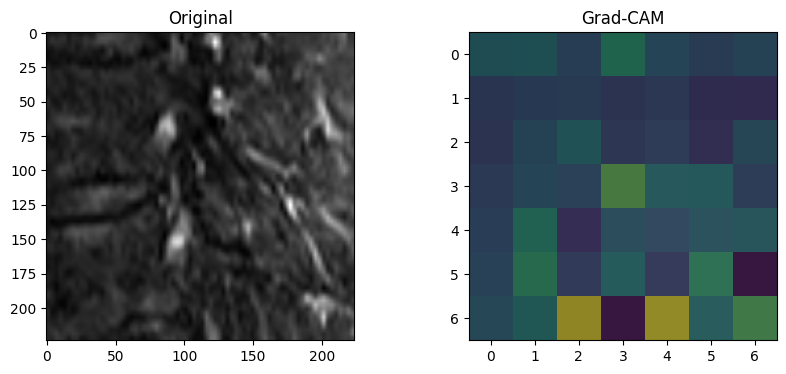

In [9]:
# 이미지 + CAM 시각화
# 원본 이미지 (첫 slice)
orig = img[0,0,0].cpu().numpy()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(orig, cmap='gray')

plt.subplot(1,2,2)
plt.title("Grad-CAM")
plt.imshow(orig, cmap='gray')
plt.imshow(cam, alpha=0.5)

plt.show()

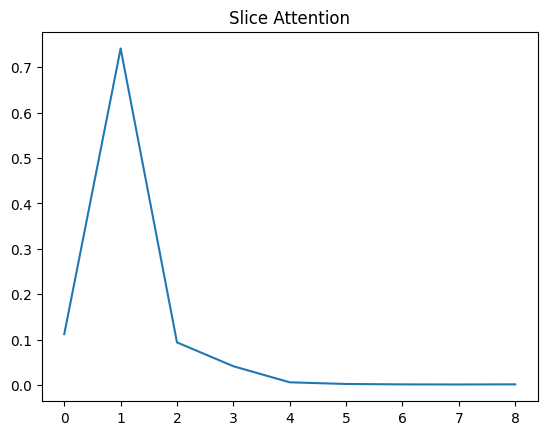

In [10]:
# attention weight
output, attn_weight = model(img)

attn = attn_weight[0].cpu().detach().numpy()

plt.figure()
plt.title("Slice Attention")
plt.plot(attn)
plt.show()

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt

DEVICE = "cuda"

import sys
sys.path.append("/home/lhe09/projects/rsna_spine/src")
from spine_dataset import build_datasets
from experiment2 import SpineModel

# 모델 로드
model = SpineModel().to(DEVICE)

model.load_state_dict(
    torch.load("/home/lhe09/projects/rsna_spine/outputs/results/best_model_convnext_coord.pth")
)

model.train()

# dropout만 끄기(선택사항)
for m in model.modules():
    if isinstance(m, torch.nn.Dropout):
        m.eval()

/tmp/ipykernel_1461/3406139749.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("/home/lhe09/projects/rsna_spine/outputs/results/best_model_convnext_coord.pth

In [13]:
_, val_dataset = build_datasets("/home/lhe09/projects/rsna_spine/outputs/roi_dataset_npy")

sample = val_dataset[0]

img = sample["image"].unsqueeze(0).to(DEVICE)   # (1, S, C, H, W)
coord = sample["coord"].unsqueeze(0).to(DEVICE)
label = sample["label"]

print(img.shape)
print(label)

Total samples: 351783
Train samples: 316604
Val samples: 35179
torch.Size([1, 9, 1, 224, 224])
tensor([0, 0, 0, 0, 1])


In [15]:
# hook 저장용 변수
features = []
gradients = []

# hook 함수
def forward_hook(module, input, output):
    features.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

# hook 등록(ConvNext 마지막 layer)
target_layer = model.backbone.stages[-1].blocks[-1]

target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

# forward + backward
output, attn_weight = model(img, coord)   # (1, 5, 3)

# 예: 첫 번째 디스크
target = output[0, 0].argmax()

model.zero_grad()
output[0, 0, target].backward()

# Grad_CAM 생성
feat = features[0]      # (B*S, C, H, W)
grad = gradients[0]

# 평균 gradient
weights = grad.mean(dim=(2,3), keepdim=True)

cam = (weights * feat).sum(dim=1)
cam = torch.relu(cam)

cam = cam[0].cpu().detach().numpy()

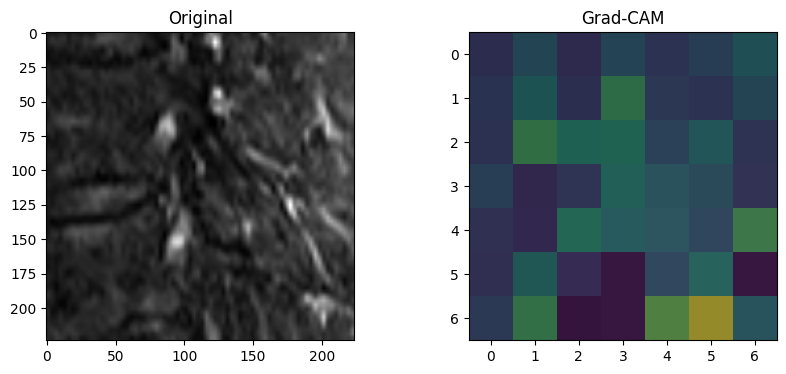

In [16]:
# 이미지 + CAM 시각화
# 원본 이미지 (첫 slice)
orig = img[0,0,0].cpu().numpy()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(orig, cmap='gray')

plt.subplot(1,2,2)
plt.title("Grad-CAM")
plt.imshow(orig, cmap='gray')
plt.imshow(cam, alpha=0.5)

plt.show()

/home/lhe09/miniconda3/envs/first/lib/python3.10/site-packages/torch/nn/modules/module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


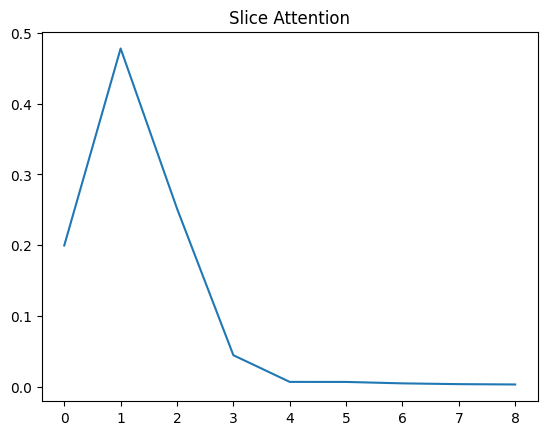

In [18]:
# attention weight
output, attn_weight = model(img, coord)

attn = attn_weight[0].cpu().detach().numpy()

plt.figure()
plt.title("Slice Attention")
plt.plot(attn)
plt.show()

In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt

DEVICE = "cuda"

import sys
sys.path.append("/home/lhe09/projects/rsna_spine/src")
from spine_dataset import build_datasets
from experiment3 import SpineModel

# 모델 로드
model = SpineModel().to(DEVICE)

model.load_state_dict(
    torch.load("/home/lhe09/projects/rsna_spine/outputs/results/best_model_convnext_transformer.pth")
)

model.train()

# dropout만 끄기(선택사항)
for m in model.modules():
    if isinstance(m, torch.nn.Dropout):
        m.eval()

/tmp/ipykernel_1461/1826919394.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("/home/lhe09/projects/rsna_spine/outputs/results/best_model_convnext_transform

In [20]:
# hook 저장용 변수
features = []
gradients = []

# hook 함수
def forward_hook(module, input, output):
    features.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

# hook 등록(ConvNext 마지막 layer)
target_layer = model.backbone.stages[-1].blocks[-1]

target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

# forward + backward
output, attn_weight = model(img)   # (1, 5, 3)

# 예: 첫 번째 디스크
target = output[0, 0].argmax()

model.zero_grad()
output[0, 0, target].backward()

# Grad_CAM 생성
feat = features[0]      # (B*S, C, H, W)
grad = gradients[0]

# 평균 gradient
weights = grad.mean(dim=(2,3), keepdim=True)

cam = (weights * feat).sum(dim=1)
cam = torch.relu(cam)

cam = cam[0].cpu().detach().numpy()

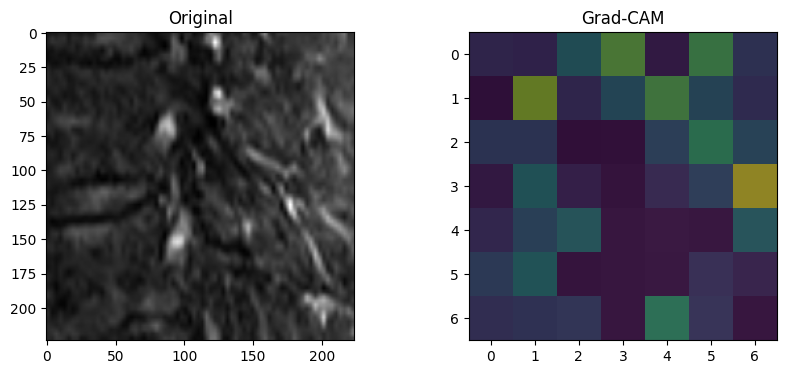

In [21]:
# 이미지 + CAM 시각화
# 원본 이미지 (첫 slice)
orig = img[0,0,0].cpu().numpy()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(orig, cmap='gray')

plt.subplot(1,2,2)
plt.title("Grad-CAM")
plt.imshow(orig, cmap='gray')
plt.imshow(cam, alpha=0.5)

plt.show()

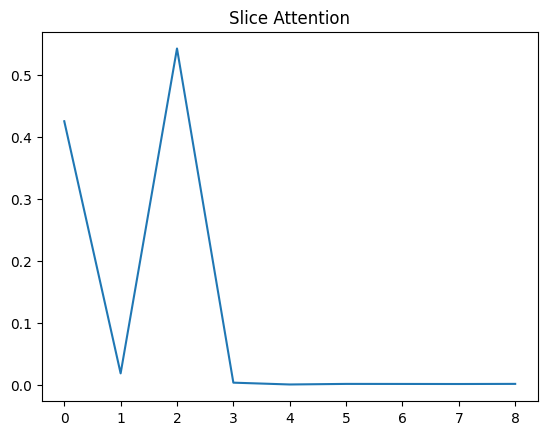

In [22]:
# attention weight
output, attn_weight = model(img)

attn = attn_weight[0].cpu().detach().numpy()

plt.figure()
plt.title("Slice Attention")
plt.plot(attn)
plt.show()

In [ ]:
# 특정 slice로 분류를 진행함....
# ??? grad-cam은  왜 다 퍼져있지???? 확인필요..
# 그래서 slice별로 CAM을 분리해 보기

In [ ]:
# experiment1의 cam은 이상한 곳을 보고 있음...
# experiment2는 그나마 조금 나음
# experiment3도 나아지긴 했지만 
# 모든 실험에서 다른 디스크간의 연결성이나 spatial의 대한 특징이 아닌, 특정 slice의 특징만으로 분류함.
# experiment3에서는 positional encoding을 제외해서 그런거 이해함.
# 나의 결론은 이 task는 순서의 상관없이 특적 feature만으로도 분류를 할 수 있어 다른 걸 활용하지 못함.(정확도가 높음)
#(단일 disc 정보만으로도 classification이 가능하기 때문에 sequence 모델이 무력화됨)
# experiment1에서는 순서를 섞어서 lstm을 잘 쓰는지 확인해야 하고, 
# experiment2에서는 coord의 좌표의 attention을 강화해야하고, 
# experiment3에서는 poistional encoding을 넣어고 노이즈를 넣어줌으로 확인해야 함. 
import torch
import numpy as np
import matplotlib.pyplot as plt

DEVICE = "cuda"

import sys
sys.path.append("/home/lhe09/projects/rsna_spine/src")
from spine_dataset import build_datasets
from experiment3 import SpineModel

# 모델 로드
model = SpineModel().to(DEVICE)

model.load_state_dict(
    torch.load("/home/lhe09/projects/rsna_spine/outputs/results/best_model_convnext_transformer.pth")
)

model.train()

# dropout만 끄기(선택사항)
for m in model.modules():
    if isinstance(m, torch.nn.Dropout):
        m.eval()

/tmp/ipykernel_1450/1191005387.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("/home/lhe09/projects/rsna_spine/outputs/results/best_model_convnext_transform

In [13]:
_, val_dataset = build_datasets("/home/lhe09/projects/rsna_spine/outputs/roi_dataset_npy")

sample = val_dataset[0]

img = sample["image"].unsqueeze(0).to(DEVICE)   # (1, S, C, H, W)
coord = sample["coord"].unsqueeze(0).to(DEVICE)
label = sample["label"]

print(img.shape)
print(label)

Total samples: 351783
Train samples: 316604
Val samples: 35179
torch.Size([1, 9, 1, 224, 224])
tensor([0, 0, 0, 0, 1])


In [15]:
# hook 저장용 변수
features = []
gradients = []

# hook 함수
def forward_hook(module, input, output):
    features.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

# hook 등록(ConvNext 마지막 layer)
target_layer = model.backbone.stages[-1].blocks[-1]

target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

# forward + backward
output, attn_weight = model(img)   # (1, 5, 3)

# 예: 첫 번째 디스크
target = output[0, 0].argmax()

model.zero_grad()
output[0, 0, target].backward()

# Grad_CAM 생성
feat = features[0]      # (B*S, C, H, W)
grad = gradients[0]

# 평균 gradient
weights = grad.mean(dim=(2,3), keepdim=True)

cam = (weights * feat).sum(dim=1)
cam = torch.relu(cam)


/home/lhe09/miniconda3/envs/first/lib/python3.10/site-packages/torch/nn/modules/module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


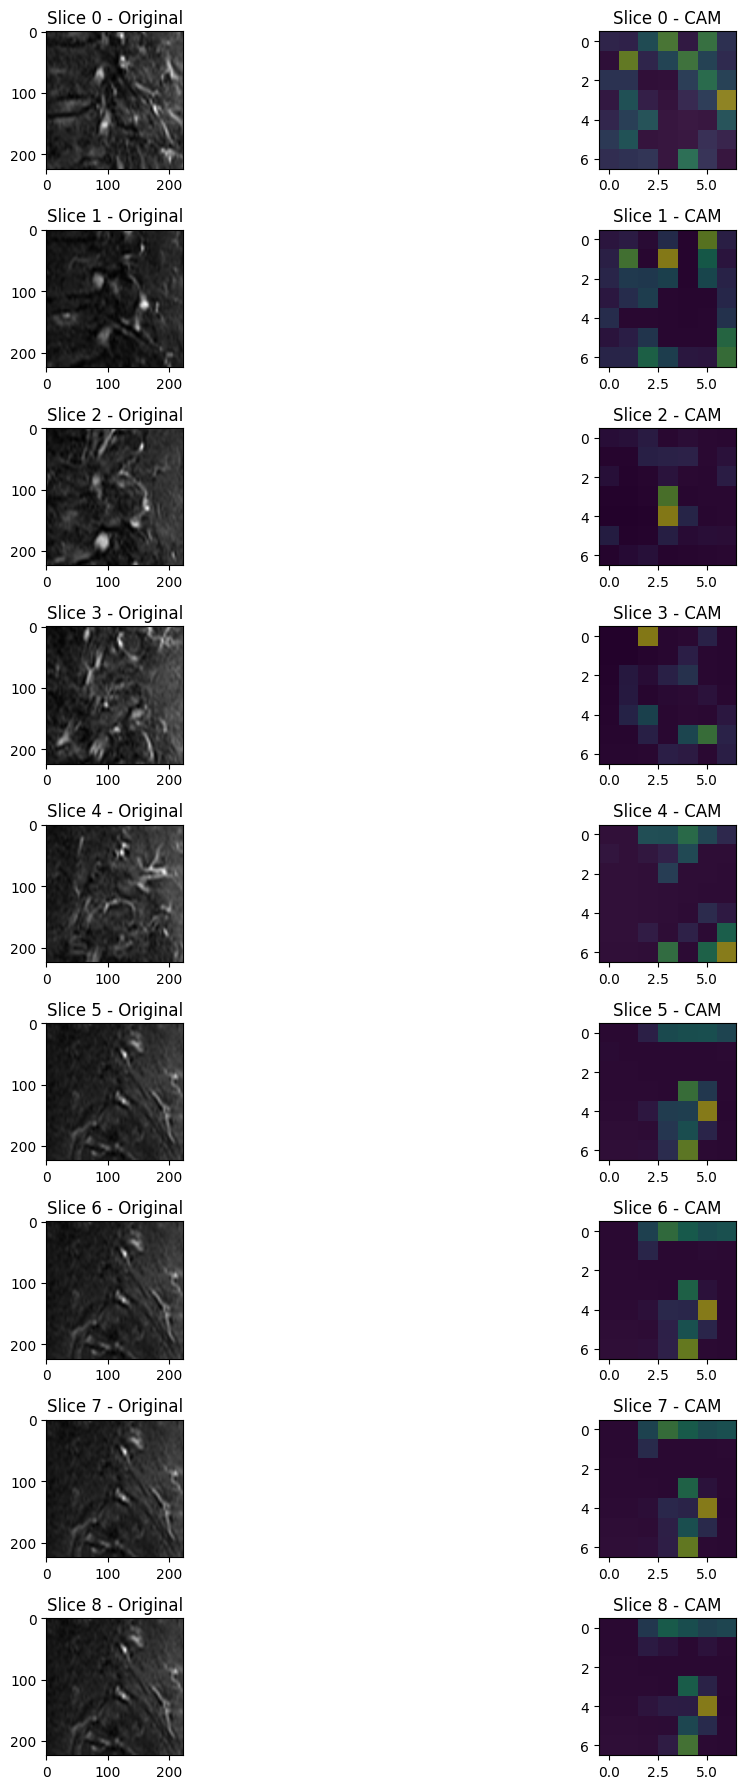

In [16]:
# slice별로 reshape
B, S, C, H, W = img.shape

cam = cam.view(B, S, cam.shape[-2], cam.shape[-1])   # (B, S, H, W)
cam = cam[0]   # (S, H, W)

# normalization
cam = cam.detach().cpu().numpy()

# slice별 normalize
for i in range(cam.shape[0]):
    cam[i] = (cam[i] - cam[i].min()) / (cam[i].max() + 1e-8)

# 이미지도 slice별로 준비
orig = img[0].cpu().numpy() # (S, 1, H, W)
orig = orig[:,0]            # (S, H, W)

# slice별 시각화
import matplotlib.pyplot as plt

S = cam.shape[0]

plt.figure(figsize=(15, S*2))

for i in range(S):
    plt.subplot(S, 2, 2*i+1)
    plt.title(f"Slice {i} - Original")
    plt.imshow(orig[i], cmap='gray')

    plt.subplot(S, 2, 2*i+2)
    plt.title(f"Slice {i} - CAM")
    plt.imshow(orig[i], cmap='gray')
    plt.imshow(cam[i], alpha=0.5)

plt.tight_layout()
plt.show()

Attention: [[0.40744784]
 [0.02054434]
 [0.5591793 ]
 [0.00377325]
 [0.00105395]
 [0.00196334]
 [0.00195307]
 [0.00195528]
 [0.00212963]]
Max attention slice: 2


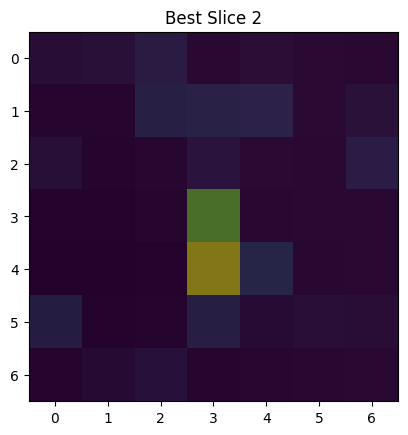

In [17]:
# attention 이랑 같이 보기
attn = attn_weight[0].detach().cpu().numpy()

print("Attention:", attn)
print("Max attention slice:", attn.argmax())

best_slice = attn.argmax()

plt.imshow(orig[best_slice], cmap='gray')
plt.imshow(cam[best_slice], alpha=0.5)
plt.title(f"Best Slice {best_slice}")
plt.show()

In [9]:
# experiment1에서 lstm을 쓰는지 검증
import torch

def shuffle_sequence(x):
    B, S, C, H, W = x.shape
    idx = torch.randperm(S)
    x_shuffled = x[:, idx]  # sequence만 섞기
    return x_shuffled, idx

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt

DEVICE = "cuda"

import sys
sys.path.append("/home/lhe09/projects/rsna_spine/src")
from spine_dataset import build_datasets
from experiment3 import SpineModel

# 모델 로드
model = SpineModel().to(DEVICE)

model.load_state_dict(
    torch.load("/home/lhe09/projects/rsna_spine/outputs/results/best_model_convnext_transformer.pth")
)

/tmp/ipykernel_24730/2038274153.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("/home/lhe09/projects/rsna_spine/outputs/results/best_model_convnext_transfor

<All keys matched successfully>

In [10]:
_, val_dataset = build_datasets("/home/lhe09/projects/rsna_spine/outputs/roi_dataset_npy")
from torch.utils.data import DataLoader

val_loader = DataLoader(
    val_dataset,
    batch_size=8,   # 적당히
    shuffle=False
)

Total samples: 351783
Train samples: 316604
Val samples: 35179


In [11]:
for batch in val_loader:
    img = batch["image"]
    label = batch["label"]

    print("img shape:", img.shape)
    print("label:", label)
    print("label min/max:", label.min(), label.max())
    print("label dtype:", label.dtype)

    break

img shape: torch.Size([8, 9, 1, 224, 224])
label: tensor([[0, 0, 0, 0, 1],
        [0, 1, 1, 2, 1],
        [1, 1, 0, 1, 0],
        [0, 0, 0, 1, 1],
        [0, 0, 1, 0, 0],
        [0, 0, 1, 1, 0],
        [0, 0, 1, 0, 0],
        [0, 1, 0, 1, 0]])
label min/max: tensor(0) tensor(2)
label dtype: torch.int64


In [12]:
model.eval()

correct_orig = 0
correct_shuffle = 0
total = 0

with torch.no_grad():
    for batch in val_loader:
        img = batch["image"].to(DEVICE)
        coord = batch["coord"].to(DEVICE)
        label = batch["label"].to(DEVICE)

        # 🔵 원래
        out_orig, _ = model(img)
        
        # 🔴 shuffle
        img_shuffled, idx = shuffle_sequence(img)

        #out_shuffle, _ = model(img_shuffled, coord)
        out_shuffle, _ = model(img_shuffled)

        pred_orig = out_orig.argmax(dim=2)
        pred_shuffle = out_shuffle.argmax(dim=2)

        correct_orig += (pred_orig == label).sum().item()
        correct_shuffle += (pred_shuffle == label).sum().item()
        total += label.numel()

print("Original Acc:", correct_orig / total)
print("Shuffled Acc:", correct_shuffle / total)

Original Acc: 0.9196159455517744
Shuffled Acc: 0.9196159455517744


In [ ]:
# experiment1
#Original Acc: 0.7464025279533301
#Shuffled Acc: 0.739487117160914
#“각 disc patch만으로도 충분한 classification 성능이 확보되면서,
#sequence 모델(LSTM, Transformer)은 실제로 관계 정보를 학습하지 않는 현상을 확인하였다.”
#“이를 검증하기 위해 sequence order를 무작위로 섞는 실험을 수행했으며,
#성능 저하가 거의 발생하지 않음을 통해 모델이 sequence 정보를 활용하지 않음을 확인하였다.”

# experiment2
#Original Acc: 0.7980432668935342
#Shuffled Acc: 0.7891711229946524
# coord 위치 bias로 성능 향상에 기여함.(experiment1,2비교)
#“좌표 정보(coord)는 sequence 관계 학습을 유도하지 못하고,
#단순한 위치 bias로 작용하여 성능 향상에만 기여한다.”

# experiment3
#Original Acc: 0.9196159455517744
#Shuffled Acc: 0.9196159455517744
#“Transformer는 self-attention을 통한 feature reweighted 및 aggregation 역할로 작용하여 성능이 높은 것으로 해석됨.
# feature mixing 때문에"

## 최종 : “모델의 한계가 아니라 데이터 구조의 특성으로 인해 sequence 학습이 불필요한 문제임을 확인하였다.”
